# First Day Quantum Computing Lab

## Understanding Superposition, Measurement, Entanglement, and the Bloch Sphere

This notebook is designed as a **first-day programming activity** for students beginning quantum computing with Qiskit.

### What you will learn
By the end of this lab, you should be able to:
- build a simple quantum circuit
- create a superposition state
- run a circuit on a simulator and interpret measurement counts
- create a basic entangled state
- connect one-qubit states to the **Bloch Sphere**
- explain what common gates such as **H**, **X**, and **Z** do to a qubit

### How to use this notebook
For each section:
1. Read the explanation.
2. Run the code.
3. Answer the short activity questions.
4. Modify the code where asked and observe what changes.


## 1. Setup

The next cell imports the main Qiskit tools used in this notebook.

- `QuantumCircuit` is used to build circuits.
- `AerSimulator` runs the circuit on a simulator.
- `plot_histogram` helps us visualise measurement outcomes.
- `Statevector` lets us examine the state before measurement.
- `plot_bloch_multivector` helps us visualise a single-qubit state on the Bloch Sphere.


In [1]:
import qiskit as qk
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector
import numpy as np
import math

# Uncomment this line if needed in Jupyter
# %matplotlib inline

## 2. Warm-up: a qubit in superposition

A classical bit must be either **0** or **1**.

A qubit can also be in a **superposition** of both basis states.  
One of the easiest ways to create superposition is to apply a **Hadamard gate (`H`)** to \(|0\rangle\).

### What should happen?
If we apply `H` to a qubit that starts in \(|0\rangle\), the state becomes:

\[
\frac{|0\rangle + |1\rangle}{\sqrt{2}}
\]

When measured many times, we expect roughly:
- 50% outcome `0`
- 50% outcome `1`


Circuit:


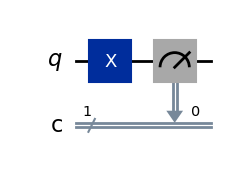

Measurement counts: {'1': 1024}


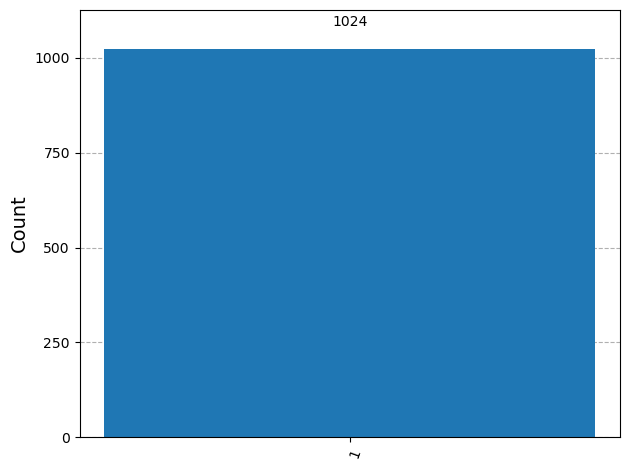

In [3]:
# Example 1: One qubit in superposition
qc1 = QuantumCircuit(1, 1)

# Apply Hadamard gate
qc1.x(0)

# Measure the qubit
qc1.measure(0, 0)

print("Circuit:")
display(qc1.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc1, shots=1024)
result = job.result()
counts = result.get_counts(qc1)

print("Measurement counts:", counts)
plot_histogram(counts)

### Class activity 1
Answer these questions after running the cell above:

1. Why do we not get only `0` as the result?
2. Are the counts exactly equal? Why or why not?
3. What do you think will happen if the `H` gate is removed?

### Try it yourself
Modify the circuit:
- remove the `H` gate and run again
- replace `qc1.h(0)` with `qc1.x(0)` and run again

Write one sentence explaining each outcome.


1. Putting the qubit in superposition via the Hadamard gate gives us the cahnce of 50 percent for getting 0 and 50 percent of getting 1 when measured.
2. No,there won't be equality as the measurements are probabilistic, thus we will have approximately 512 for each with 1024 shots being made.
3. Without the H gate, the qubit remains in the 0 state and thus, all results will be 0. 

1. The qubit stays in 0 state because we don't applied any gate, so measurement always returns 0.
2. The X gate flips 0 to 1, so measuring always returns 1. It's now a classical deterministic bit flip, no superposition.

## 3. Two qubits in superposition

Now let us extend the idea to **two qubits**.

If we apply a Hadamard gate to both qubits, each qubit goes into superposition independently.  
After measurement, we expect to see four possible outcomes:

- `00`
- `01`
- `10`
- `11`

Each should appear with roughly equal probability.


Circuit:


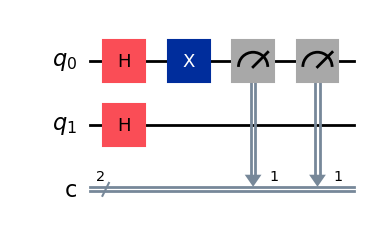

Measurement counts: {'00': 501, '10': 523}


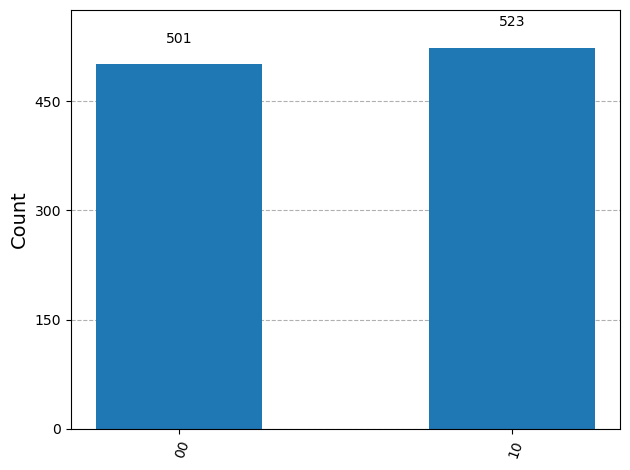

In [5]:
# Example 2: Two qubits in superposition
qc2 = qk.QuantumCircuit(2, 2)

qc2.h(0)
qc2.h(1)
qc2.x(0)

qc2.measure(0, 1)
qc2.measure(0, 1)

print("Circuit:")
display(qc2.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc2, shots=1024)
result = job.result()
counts = result.get_counts(qc2)

print("Measurement counts:", counts)
plot_histogram(counts)

### Class activity 2
Discuss with a partner:

1. Why are there four possible outputs now?
2. Which output appears most often? Is that what you expected?
3. If you apply `X` to qubit 0 before the `H`, how does the result change?

### Extension
Try the following one at a time:
- apply `X` on qubit 0 before measurement
- apply `Z` on qubit 0 before measurement
- measure only one qubit and leave the other unmeasured

What do you observe?


1. There are two qubits in superposition, they can have states 0 and 1 independently. Therefore, total possibilities= 2*2=4.
2. There would be an equal number for each, 25%, although because of the randomization process, any one or two of them could shown up as a larger number out of 1024.
3. X flip qubit 0 to 1, while H takes it back to 50/50 probability superpostion state, resulting in getting all four output combination.


## 4. Entanglement

Entanglement is one of the most important ideas in quantum computing.

In this section, we create an entangled pair using:
1. a **Hadamard** gate on the first qubit
2. a **CNOT** gate from the first qubit to the second

This creates the Bell state:

\[
\frac{|00\rangle + |11\rangle}{\sqrt{2}}
\]

### What should happen?
When measured many times, the outcomes should be mostly:
- `00`
- `11`

The key point is that the two qubits are **correlated**.


Circuit:


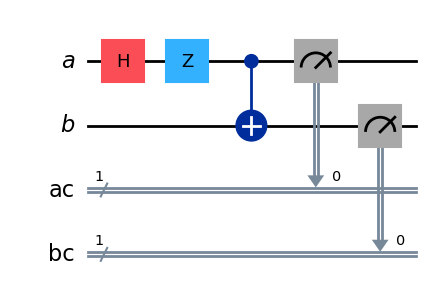

Measurement counts: {'0 0': 2018, '1 1': 2078}


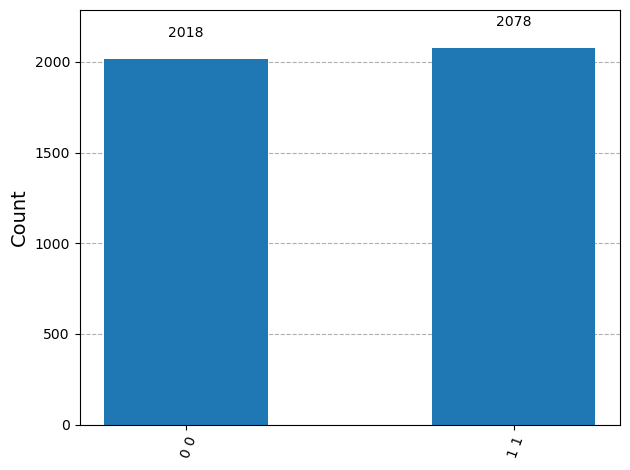

In [7]:
# Example 3: Entangled qubits
a = QuantumRegister(1, name='a')
b = QuantumRegister(1, name='b')
a_c = ClassicalRegister(1, name='ac')
b_c = ClassicalRegister(1, name='bc')

qc3 = QuantumCircuit(a, b, a_c, b_c)

qc3.h(a[0])
qc3.z(a[0]) # phase flip on a
qc3.cx(a[0], b[0])
qc3.measure(a[0], a_c[0])
qc3.measure(b[0], b_c[0])

print("Circuit:")
display(qc3.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc3, shots=4096)
result = job.result()
counts = result.get_counts(qc3)

print("Measurement counts:", counts)
plot_histogram(counts)

### Class activity 3
After running the entanglement example, answer:

1. Why do we mainly see `00` and `11`, but not `01` and `10`?
2. How is this different from the earlier two-qubit superposition example?
3. What role does the `cx` gate play?

### Try it yourself
Change the circuit and test:
- remove the `cx` gate
- apply `x` to qubit `b` before measurement
- apply `z` to qubit `a` before the `cx`

Describe what changes in the histogram.


1. The CNOT gate entangles qubits A and B after passing them through H gate, where A qubit is 50/50 probability state. The CNOT gate changes B qubit state depending on state of qubit A:0 becomes 0 and 1 becomes 1. That means 01 and 10 output combination can neverr happen.
2. Without CNOT gates qubits were not entangled, resulting in all four combination possible. With CNOT gate applied qubits became entangled and only 00 and 11 combinations can be achieved.
3. The CX gate makes qubits entangled by flipping target qubit only if the state of control qubit is 1.

## 5. Bloch Sphere intuition for a single qubit

The **Bloch Sphere** is a visual way to represent the state of **one qubit**.

### Key reference points
- \(|0\rangle\) is at the **north pole**
- \(|1\rangle\) is at the **south pole**
- superposition states lie at other points on the sphere
- pure states lie on the **surface** of the sphere

You can think of common gates as rotations or flips on this sphere.


Statevector for |0>: Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


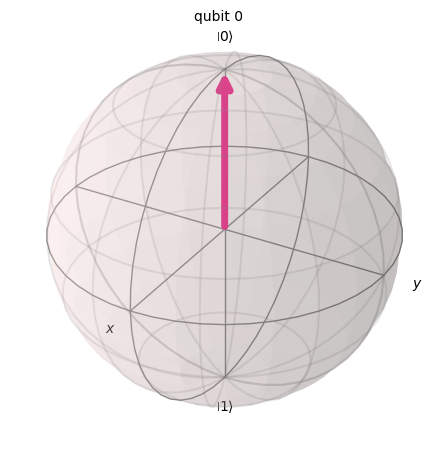

In [8]:
# Bloch Sphere for |0>
qc_b0 = QuantumCircuit(1)
state_b0 = Statevector.from_instruction(qc_b0)

print("Statevector for |0>:", state_b0)
plot_bloch_multivector(state_b0)

Statevector for |1>: Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


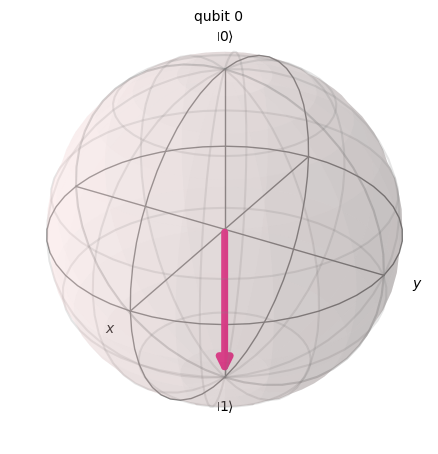

In [9]:
# Bloch Sphere for |1>
qc_b1 = QuantumCircuit(1)
qc_b1.x(0)
state_b1 = Statevector.from_instruction(qc_b1)

print("Statevector for |1>:", state_b1)
plot_bloch_multivector(state_b1)

Statevector for H|0>: Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


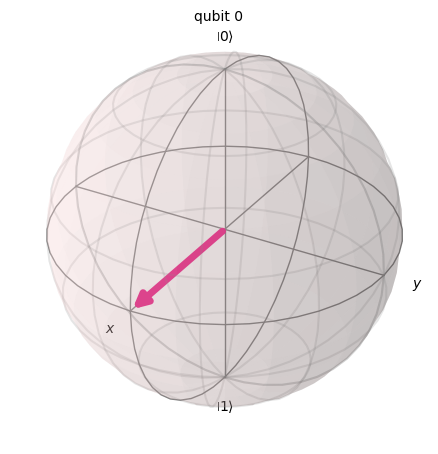

In [10]:
# Bloch Sphere for H|0>
qc_bh = QuantumCircuit(1)
qc_bh.h(0)
state_bh = Statevector.from_instruction(qc_bh)

print("Statevector for H|0>:", state_bh)
plot_bloch_multivector(state_bh)

### Class activity 4
For each state above, identify whether the point is:
- near the north pole
- near the south pole
- on the equator

Then answer:
1. Where is \(|0\rangle\)?
2. Where is \(|1\rangle\)?
3. What type of state is created by `H|0>`?
4. Why is the Bloch Sphere mainly useful for only one qubit?


1. North pole(z+ axis)
2. South pole(z- axis)
3. on the equator(x+ axis)

## 6. Gate effects on the Bloch Sphere

Now let us see how gates move a state around the sphere.

### Predictions before running
Before you run each cell, predict what will happen:
- Will the state flip from top to bottom?
- Will it remain on the equator?
- Will it rotate around an axis?


Statevector after X|0>: Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


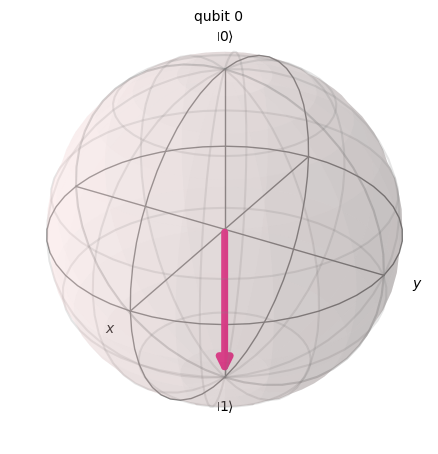

In [11]:
# X gate on |0>
qc_x = QuantumCircuit(1)
qc_x.x(0)
state_x = Statevector.from_instruction(qc_x)

print("Statevector after X|0>:", state_x)
plot_bloch_multivector(state_x)

Statevector after ZH|0>: Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))


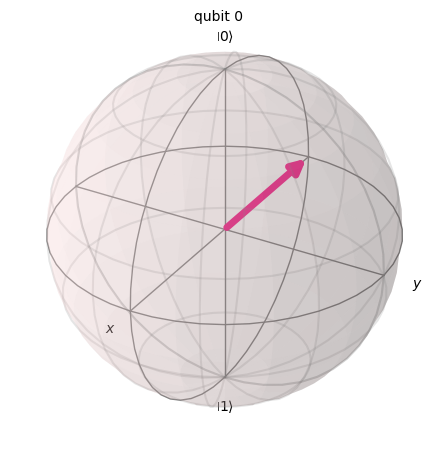

In [12]:
# Z gate after H
qc_z = QuantumCircuit(1)
qc_z.h(0)
qc_z.z(0)
state_z = Statevector.from_instruction(qc_z)

print("Statevector after ZH|0>:", state_z)
plot_bloch_multivector(state_z)

Statevector after XH|0>: Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


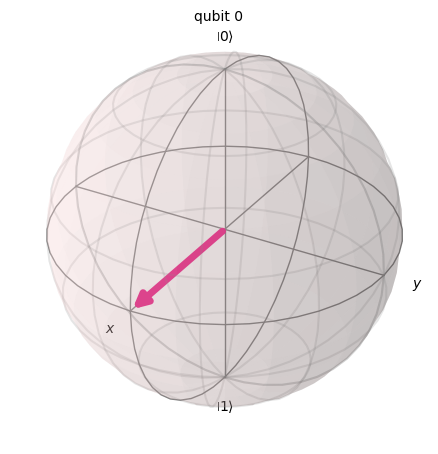

In [13]:
# H followed by X
qc_hx = QuantumCircuit(1)
qc_hx.h(0)
qc_hx.x(0)
state_hx = Statevector.from_instruction(qc_hx)

print("Statevector after XH|0>:", state_hx)
plot_bloch_multivector(state_hx)

### Class activity 5
Complete the table below in your notes.

| Circuit | Your prediction | What you observed |
|---|---|---|
| `X|0>` |  |  |
| `ZH|0>` |  |  |
| `XH|0>` |  |  |

Then answer:
1. Which gate produced a clear flip between \(|0\rangle\) and \(|1\rangle\)?
2. Which gate changed the phase of a superposition state?
3. Why can two states give different Bloch positions even when probabilities may look similar?


## 7. Student mini-challenge

Create your own one-qubit circuit using any combination of:
- `h`
- `x`
- `y`
- `z`
- `s`
- `t`

### Your task
1. Build a circuit with at least **two gates**.
2. Predict the Bloch Sphere position before running it.
3. Plot the Bloch Sphere.
4. Write a 3 to 5 line explanation of what happened.

Use the cell below.


Your circuit:


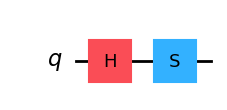

Statevector: Statevector([0.70710678+0.j        , 0.        +0.70710678j],
            dims=(2,))


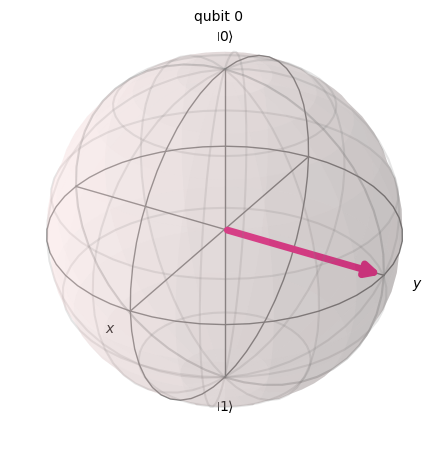

In [14]:
# Student challenge cell
qc_student = QuantumCircuit(1)

# Example: replace these with your own gates
qc_student.h(0)
qc_student.s(0)

print("Your circuit:")
display(qc_student.draw(output='mpl'))

state_student = Statevector.from_instruction(qc_student)
print("Statevector:", state_student)
plot_bloch_multivector(state_student)

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import matplotlib.pyplot as plt

qc_student = QuantumCircuit(1)

qc_student.h(0)  # H: |0> -> |+> on +X equator
qc_student.t(0)  # T: rotate 45° around Z-axis

print("Your circuit:")
display(qc_student.draw(output='mpl'))

state_student = Statevector.from_instruction(qc_student)
print("Statevector:", state_student)
plot_bloch_multivector(state_student)
plt.show()

1. Used two gates H and T
2. H|0> = puts the qubit on the equator at the right side → +XT = spins it 45° around, toward you → halfway between +X and +Y
3. Running gives statevector: [0.707+0j, 0.5+0.5j]
Bloch vector: [0.707, 0.707, 0] → Exactly halfway between +X and +Y, still on equator.
4. The H gate created an equal superposition ∣+⟩, placing the qubit on the +X axis of the Bloch sphere equator. The T gate applied a 45° phase rotation around the Z-axis, which moved the state along the equator toward +Y without changing Z. Measurement would still give 50/50 for 0 and 1, but the relative phase is now π/4 instead of 0. This shows how T changes phase while H creates superposition.

## 8. Reflection questions

Write short answers for the following:

1. What is the difference between a classical bit and a qubit?
2. What does the Hadamard gate do?
3. How is an entangled state different from two independent qubits in superposition?
4. What does the Bloch Sphere help us understand?
5. Which part of today's lab did you find the most interesting or confusing?


## 9. Optional assessment task

Submit the following:
- one screenshot of a circuit you created
- one histogram or Bloch Sphere output
- a short explanation of what your circuit does

### Suggested marking focus
- correctness of circuit
- interpretation of results
- ability to connect code with concept
